# 推理服務架構：產線LLM端到端系統設計

> **難度：** 進階 | **時長：** 約四十分鐘

本系列歷來構建高效LLM推理之核心要件——KV-cache（第00篇）、FlashAttention（01）、continuous batching（02）、PagedAttention（03）、prefix caching（04）、quantization（05）、speculative decoding（06）與guided generation（07）。每者解一瓶頸。產線之上，諸法須協同運作於一**服務系統**之中，路由請求、調度GPU工作、管理記憶體、串流token歸於用戶。

此收官篇取**架構**視角。本篇將：

1. 繪製現代LLM服務棧之端到端組件架構
2. 探索**prefill / decode disaggregation**——何以分離二階段於不同worker
3. 設計**PD Connector**以於prefill與decode workers間傳輸KV-cache
4. 審視**distributed KV-cache store**之串聯機制
5. 追蹤完整**請求生命周期**——自客戶端至串流響應
6. 比較真實服務框架：vLLM、TGI與TensorRT-LLM

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.plantuml import render_plantuml
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
## 一、端到端架構概覽

產線LLM服務系統遠不止一模型於循環中運行。乃一分布式系統，組件各司其職：

| 組件 | 職責 |
|-----------|---------------|
| **API Gateway / Router** | 接受HTTP/gRPC請求，認證、限速、路由至後端 |
| **Scheduler** | 決定何請求運行、何時搶佔、如何組批 |
| **Prefill Workers** | 處理輸入prompt（compute-bound階段） |
| **Decode Workers** | 自回歸生成輸出token（memory-bound階段） |
| **KV-Cache Store** | 管理分布式block table、page分配、copy-on-write |
| **PD Connector** | 自prefill向decode workers傳輸KV-cache |
| **Streaming Proxy** | 多路復用SSE/WebSocket串流歸於客戶端 |

以下組件圖展示各部之連接。

In [2]:
render_plantuml("""
@startuml
skinparam componentStyle rectangle
skinparam backgroundColor white
skinparam defaultFontSize 13

actor "Client" as client

package "API Layer" {
  [API Gateway\n/ Router / LB] as router
}

package "Orchestration" {
  [Scheduler] as sched
  [Batch Manager] as batcher
}

package "Compute Pool" {
  [Prefill Worker 0\n(GPU, compute-bound)] as pw0
  [Prefill Worker 1\n(GPU, compute-bound)] as pw1
  [Decode Worker 0\n(GPU, memory-bound)] as dw0
  [Decode Worker 1\n(GPU, memory-bound)] as dw1
  [Decode Worker 2\n(GPU, memory-bound)] as dw2
}

package "Memory Layer" {
  [KV-Cache Store\n(Distributed Block Manager)] as kvstore
  [PD Connector\n(RDMA / NVLink / TCP)] as pdconn
}

package "Response" {
  [Streaming Proxy\n(SSE / WebSocket)] as stream
}

client --> router : HTTP/gRPC
router --> sched : enqueue request
sched --> batcher : form batch
batcher --> pw0 : prefill batch
batcher --> pw1 : prefill batch
pw0 --> pdconn : KV-cache blocks
pw1 --> pdconn : KV-cache blocks
pdconn --> dw0 : transfer KV
pdconn --> dw1 : transfer KV
pdconn --> dw2 : transfer KV
dw0 --> kvstore : alloc / free pages
dw1 --> kvstore : alloc / free pages
dw2 --> kvstore : alloc / free pages
pw0 --> kvstore : populate pages
pw1 --> kvstore : populate pages
dw0 --> stream : tokens
dw1 --> stream : tokens
dw2 --> stream : tokens
stream --> client : SSE stream

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam componentStyle rectangle
skinparam backgroundColor white
skinparam defaultFontSize 13

actor "Client" as client

package "API Layer" {
  [API Gateway
/ Router / LB] as router
}

package "Orchestration" {
  [Scheduler] as sched
  [Batch Manager] as batcher
}

package "Compute Pool" {
  [Prefill Worker 0
(GPU, compute-bound)] as pw0
  [Prefill Worker 1
(GPU, compute-bound)] as pw1
  [Decode Worker 0
(GPU, memory-bound)] as dw0
  [Decode Worker 1
(GPU, memory-bound)] as dw1
  [Decode Worker 2
(GPU, memory-bound)] as dw2
}

package "Memory Layer" {
  [KV-Cache Store
(Distributed Block Manager)] as kvstore
  [PD Connector
(RDMA / NVLink / TCP)] as pdconn
}

package "Response" {
  [Streaming Proxy
(SSE / WebSocket)] as stream
}

client --> router : HTTP/gRPC
router --> sched : enqueue request
sched --> batcher : form batch
batcher --> pw0 : prefill batch
batcher --> pw1 : prefill batch
pw0 --> pdconn : KV-cache blocks
pw1 --> pdconn : KV-cache blocks
pdconn --> dw0 : transfer KV
pdconn --> dw1 : transfer KV
pdconn --> dw2 : transfer KV
dw0 --> kvstore : alloc / free pages
dw1 --> kvstore : alloc / free pages
dw2 --> kvstore : alloc / free pages
pw0 --> kvstore : populate pages
pw1 --> kvstore : populate pages
dw0 --> stream : tokens
dw1 --> stream : tokens
dw2 --> stream : tokens
stream --> client : SSE stream

@enduml
```

此圖揭示現代服務系統之關鍵架構抉擇：**prefill與decode為分離之worker池**，經KV-cache傳輸層相連。此即**prefill/decode disaggregation**，乃本篇之核心議題。

---
## 二、Prefill / Decode Disaggregation

回顧第00篇（KV-Cache），LLM推理有二階段，計算特徵迥異：

| 性質 | Prefill | Decode |
|----------|---------|--------|
| **處理之token** | 一次處理全部prompt token（數百至數千） | 每步一新token |
| **瓶頸** | Compute-bound（arithmetic intensity高） | Memory-bound（arithmetic intensity低） |
| **GPU利用率** | 高（大矩陣乘法） | 低（多數時間載入權重） |
| **延遲目標** | Time-to-first-token (TTFT) | Inter-token latency (ITL) |
| **最佳batch size** | 小batch（每請求本身已並行） | 大batch（攤薄權重載入） |

### 何以拆分？

若prefill與decode共享同一GPU，則彼此**干擾**：

- 長prefill阻塞decode步驟，致所有在途請求之token生成**停滯**
- Decode欲以大batch攤薄記憶體頻寬；prefill欲以小batch最小化TTFT
- 最優GPU類型有異：prefill得益於高FLOPS（A100/H100），decode得益於高記憶體頻寬（常為同型GPU，然batch配置不同）

拆分為獨立worker池，則各可**獨立擴展與優化**。

In [3]:
info_box(
    "Prefill/decode disaggregation was popularized by systems like Splitwise (2024) "
    "and DistServe (2024). The core insight: mixing compute-bound and memory-bound "
    "workloads on the same GPU leads to suboptimal utilization for both. Separating "
    "them allows each pool to be tuned independently — different batch sizes, different "
    "parallelism strategies, even different GPU types.",
    title="Historical context"
)

In [4]:
# Quantify the utilization gap between prefill and decode

# A100 specs
a100_tflops = 312  # BF16 TFLOPS
a100_membw_tbs = 2.0  # TB/s HBM bandwidth
roofline_intensity = a100_tflops / a100_membw_tbs  # FLOPs/byte at roofline knee

d_model = 4096
n_layers = 32
model_params = 7e9
bytes_per_param = 2  # FP16
model_bytes = model_params * bytes_per_param

# Arithmetic intensity = FLOPs / bytes_loaded
# For linear layers: 2 * params * batch_tokens FLOPs, model_bytes loaded

scenarios = [
    ("Prefill (512 tokens)",  512),
    ("Prefill (2048 tokens)", 2048),
    ("Decode (batch=1)",      1),
    ("Decode (batch=8)",      8),
    ("Decode (batch=64)",     64),
    ("Decode (batch=256)",    256),
]

print(f"A100 roofline knee: {roofline_intensity:.0f} FLOPs/byte")
print(f"{'Scenario':<25} | {'Tokens':>7} | {'Intensity':>12} | {'Bound':>14} | {'Utilization':>11}")
print("-" * 80)

for label, tokens in scenarios:
    flops = 2 * model_params * tokens
    mem_loaded = model_bytes  # must load all weights
    intensity = flops / mem_loaded
    
    if intensity >= roofline_intensity:
        # Compute-bound: utilization = 1.0 (idealized)
        bound = "Compute-bound"
        utilization = min(1.0, intensity / roofline_intensity)  # capped at 1
        utilization = 1.0  # saturating compute
    else:
        # Memory-bound: utilization = intensity / roofline
        bound = "Memory-bound"
        utilization = intensity / roofline_intensity
    
    print(f"{label:<25} | {tokens:>7} | {intensity:>9.0f} F/B | {bound:>14} | {utilization:>10.1%}")

A100 roofline knee: 156 FLOPs/byte
Scenario                  |  Tokens |    Intensity |          Bound | Utilization
--------------------------------------------------------------------------------
Prefill (512 tokens)      |     512 |       512 F/B |  Compute-bound |     100.0%
Prefill (2048 tokens)     |    2048 |      2048 F/B |  Compute-bound |     100.0%
Decode (batch=1)          |       1 |         1 F/B |   Memory-bound |       0.6%
Decode (batch=8)          |       8 |         8 F/B |   Memory-bound |       5.1%
Decode (batch=64)         |      64 |        64 F/B |   Memory-bound |      41.0%
Decode (batch=256)        |     256 |       256 F/B |  Compute-bound |     100.0%


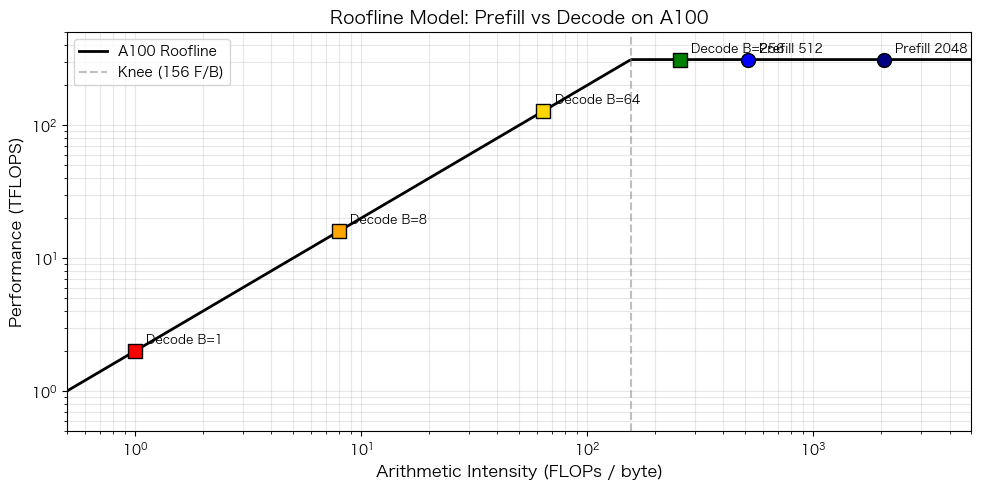

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Roofline model visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# A100 specs
peak_tflops = 312
peak_membw = 2.0  # TB/s
knee = peak_tflops / peak_membw  # 156

intensities = np.logspace(-1, 4, 500)
perf = np.minimum(intensities * peak_membw, peak_tflops)

ax.loglog(intensities, perf, 'k-', linewidth=2, label='A100 Roofline')
ax.axvline(knee, color='gray', linestyle='--', alpha=0.5, label=f'Knee ({knee:.0f} F/B)')

# Plot scenarios
points = [
    ('Decode B=1',   1,    'red',    's', 12),
    ('Decode B=8',   8,    'orange', 's', 12),
    ('Decode B=64',  64,   'gold',   's', 12),
    ('Decode B=256', 256,  'green',  's', 12),
    ('Prefill 512',  512,  'blue',   'o', 12),
    ('Prefill 2048', 2048, 'navy',   'o', 12),
]

for label, tokens, color, marker, size in points:
    ai = 2 * model_params * tokens / model_bytes  # = tokens (for FP16)
    achieved = min(ai * peak_membw, peak_tflops)
    ax.scatter(ai, achieved, c=color, marker=marker, s=100, zorder=5, edgecolors='black')
    ax.annotate(label, (ai, achieved), textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.set_xlabel('Arithmetic Intensity (FLOPs / byte)', fontsize=12)
ax.set_ylabel('Performance (TFLOPS)', fontsize=12)
ax.set_title('Roofline Model: Prefill vs Decode on A100', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0.5, 5000)
ax.set_ylim(0.5, 500)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Roofline圖直觀呈現：**小batch decode浪費逾99%之GPU計算**。Prefill則輕易飽和計算單元。Disaggregation使我們得以：

- 以**大batch**運行decode（數百請求），推其接近roofline拐點
- 以**小而延遲優化之batch**運行prefill，縮短time-to-first-token
- 依流量模式**獨立擴展**prefill與decode池

### 實踐中之擴展比例

Prefill與decode workers之比例視工作負載而定：

| 工作負載 | 輸入/輸出比 | Prefill:Decode比例 |
|----------|-------------------|---------------------|
| Chatbot（短prompt，長回覆） | 低 | 1:4或1:8 |
| 摘要（長文檔，短輸出） | 高 | 1:1或2:1 |
| 代碼補全（中等上下文，短輸出） | 中 | 1:2 |
| RAG（長上下文，中等輸出） | 高 | 1:1 |

---
## 三、PD Connector設計：Workers間之KV-Cache傳輸

Disaggregation引入新挑戰：prefill worker算得prompt之KV-cache後，須將其**傳輸**至decode worker。此即**PD Connector**（Prefill-Decode Connector）之職。

單一請求之KV-cache可甚龐大。以7B模型、2048 prompt tokens、FP16計：

$$\text{KV size} = 2 \times 32\text{ layers} \times 32\text{ heads} \times 128\text{ dim} \times 2048\text{ tokens} \times 2\text{ bytes} = 1.07\text{ GB}$$

此傳輸須**迅速**——其位於prefill完成與首個decode token之間之關鍵路徑上。

In [6]:
# Calculate KV-cache transfer sizes and times for different interconnects

def kv_cache_size_gb(n_layers, n_kv_heads, head_dim, seq_len, dtype_bytes=2):
    """Size of KV-cache for one request in GB."""
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * dtype_bytes / (1024**3)

# Model configs
configs = [
    ("LLaMA-7B (MHA)",   32, 32, 128),
    ("LLaMA-70B (GQA)",  80,  8, 128),
    ("Mixtral-8x7B",     32, 8,  128),
]

# Interconnect bandwidths (GB/s, unidirectional)
interconnects = [
    ("TCP (100 GbE)",     12.5),
    ("RDMA (200 Gb IB)",  25.0),
    ("RDMA (400 Gb IB)",  50.0),
    ("NVLink (A100)",    300.0),
    ("NVLink (H100)",    450.0),
    ("Shared HBM",     2000.0),
]

seq_len = 2048
print(f"KV-Cache transfer time for seq_len={seq_len} (single request)\n")
print(f"{'Model':<20} | {'KV Size':>8}", end="")
for name, _ in interconnects:
    print(f" | {name:>15}", end="")
print()
print("-" * 130)

for model_name, layers, kv_heads, hdim in configs:
    size_gb = kv_cache_size_gb(layers, kv_heads, hdim, seq_len)
    print(f"{model_name:<20} | {size_gb:>6.2f}GB", end="")
    for ic_name, bw_gbs in interconnects:
        time_ms = size_gb / bw_gbs * 1000
        print(f" | {time_ms:>12.1f} ms", end="")
    print()

KV-Cache transfer time for seq_len=2048 (single request)

Model                |  KV Size |   TCP (100 GbE) | RDMA (200 Gb IB) | RDMA (400 Gb IB) |   NVLink (A100) |   NVLink (H100) |      Shared HBM
----------------------------------------------------------------------------------------------------------------------------------
LLaMA-7B (MHA)       |   1.00GB |         80.0 ms |         40.0 ms |         20.0 ms |          3.3 ms |          2.2 ms |          0.5 ms
LLaMA-70B (GQA)      |   0.62GB |         50.0 ms |         25.0 ms |         12.5 ms |          2.1 ms |          1.4 ms |          0.3 ms
Mixtral-8x7B         |   0.25GB |         20.0 ms |         10.0 ms |          5.0 ms |          0.8 ms |          0.6 ms |          0.1 ms


In [7]:
# Sequence diagram: PD Connector handoff
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

participant "Scheduler" as S
participant "Prefill Worker" as PW
participant "PD Connector" as PDC
participant "KV-Cache Store" as KVS
participant "Decode Worker" as DW

S -> PW : dispatch(request, prompt_tokens)
activate PW

PW -> KVS : allocate_pages(num_blocks)
KVS --> PW : page_table, block_ids

PW -> PW : run prefill forward pass
note right of PW : Compute KV for all\nprompt tokens in parallel\n(compute-bound)

PW -> KVS : write KV blocks
PW -> PDC : notify_complete(request_id, page_table)
deactivate PW

PDC -> S : prefill_done(request_id, kv_metadata)
S -> DW : schedule_decode(request_id)
activate DW

DW -> PDC : fetch_kv(request_id)
PDC -> KVS : read KV blocks
note right of PDC : Transfer via RDMA / NVLink\n(overlap with other work)
KVS --> PDC : KV data
PDC --> DW : KV blocks + page_table

DW -> DW : append to local KV-cache
loop until EOS or max_tokens
  DW -> DW : decode one token
  DW --> S : stream token
end

DW -> KVS : free_pages(block_ids)
deactivate DW

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

participant "Scheduler" as S
participant "Prefill Worker" as PW
participant "PD Connector" as PDC
participant "KV-Cache Store" as KVS
participant "Decode Worker" as DW

S -> PW : dispatch(request, prompt_tokens)
activate PW

PW -> KVS : allocate_pages(num_blocks)
KVS --> PW : page_table, block_ids

PW -> PW : run prefill forward pass
note right of PW : Compute KV for all
prompt tokens in parallel
(compute-bound)

PW -> KVS : write KV blocks
PW -> PDC : notify_complete(request_id, page_table)
deactivate PW

PDC -> S : prefill_done(request_id, kv_metadata)
S -> DW : schedule_decode(request_id)
activate DW

DW -> PDC : fetch_kv(request_id)
PDC -> KVS : read KV blocks
note right of PDC : Transfer via RDMA / NVLink
(overlap with other work)
KVS --> PDC : KV data
PDC --> DW : KV blocks + page_table

DW -> DW : append to local KV-cache
loop until EOS or max_tokens
  DW -> DW : decode one token
  DW --> S : stream token
end

DW -> KVS : free_pages(block_ids)
deactivate DW

@enduml
```

### 傳輸策略比較

傳輸機制之選擇視部署拓撲而定：

In [8]:
comparison_table(
    headers=["Method", "Bandwidth", "Latency", "Topology", "Pros", "Cons"],
    rows=[
        ["TCP/IP", "~12 GB/s", "~100 us", "Cross-node",
         "Universal, cheap", "Slow for large KV; CPU overhead"],
        ["RDMA (InfiniBand)", "25-50 GB/s", "~1-2 us", "Cross-node",
         "Zero-copy, low latency", "Requires IB hardware"],
        ["NVLink", "300-900 GB/s", "<1 us", "Intra-node",
         "Highest bandwidth", "Only within same server"],
        ["Shared GPU memory", "~2 TB/s", "~ns", "Same GPU",
         "Zero transfer cost", "No disaggregation (collocated)"],
    ],
    title="KV-Cache Transfer Mechanisms"
)

Method,Bandwidth,Latency,Topology,Pros,Cons
TCP/IP,~12 GB/s,~100 us,Cross-node,"Universal, cheap",Slow for large KV; CPU overhead
RDMA (InfiniBand),25-50 GB/s,~1-2 us,Cross-node,"Zero-copy, low latency",Requires IB hardware
NVLink,300-900 GB/s,<1 us,Intra-node,Highest bandwidth,Only within same server
Shared GPU memory,~2 TB/s,~ns,Same GPU,Zero transfer cost,No disaggregation (collocated)


### 優化：pipeline化傳輸

樸素實現待整個prefill完成後方啟動傳輸。更優之法乃**逐層pipeline化**傳輸：

1. 層$l$之prefill甫畢，即啟動其KV blocks之傳輸
2. 層$l$之KV在途時，層$l+1$仍在計算
3. 至prefill結束時，多數KV blocks已達decode worker

此可將有效傳輸延遲自完整KV-cache大小降至約一層之量。

In [9]:
# Pipelined vs non-pipelined transfer latency

n_layers = 32
kv_total_gb = kv_cache_size_gb(32, 32, 128, 2048)  # LLaMA-7B
kv_per_layer_gb = kv_total_gb / n_layers
rdma_bw = 50.0  # GB/s (400 Gb IB)

# Assume prefill takes 50ms for 2048 tokens on A100
prefill_time_ms = 50.0
prefill_per_layer_ms = prefill_time_ms / n_layers

# Non-pipelined: wait for all prefill, then transfer everything
transfer_all_ms = kv_total_gb / rdma_bw * 1000
non_pipelined_ms = prefill_time_ms + transfer_all_ms

# Pipelined: overlap transfer with computation
transfer_per_layer_ms = kv_per_layer_gb / rdma_bw * 1000
# The bottleneck is max(prefill_per_layer, transfer_per_layer)
pipeline_stage_ms = max(prefill_per_layer_ms, transfer_per_layer_ms)
# Total = prefill of first layer + pipeline stages + transfer of last layer
pipelined_ms = prefill_time_ms + transfer_per_layer_ms  # last layer's transfer

print(f"LLaMA-7B, seq_len=2048, 400 Gb/s InfiniBand")
print(f"KV-cache total: {kv_total_gb*1024:.0f} MB ({kv_per_layer_gb*1024:.1f} MB/layer)")
print(f"Prefill time: {prefill_time_ms:.0f} ms ({prefill_per_layer_ms:.1f} ms/layer)")
print(f"Transfer time (full): {transfer_all_ms:.1f} ms ({transfer_per_layer_ms:.2f} ms/layer)")
print()
print(f"Non-pipelined TTFT: {non_pipelined_ms:.1f} ms (prefill + full transfer)")
print(f"Pipelined TTFT:     {pipelined_ms:.1f} ms (prefill + last layer transfer)")
print(f"Savings:            {non_pipelined_ms - pipelined_ms:.1f} ms ({(1 - pipelined_ms/non_pipelined_ms)*100:.0f}% faster)")

LLaMA-7B, seq_len=2048, 400 Gb/s InfiniBand
KV-cache total: 1024 MB (32.0 MB/layer)
Prefill time: 50 ms (1.6 ms/layer)
Transfer time (full): 20.0 ms (0.62 ms/layer)

Non-pipelined TTFT: 70.0 ms (prefill + full transfer)
Pipelined TTFT:     50.6 ms (prefill + last layer transfer)
Savings:            19.4 ms (28% faster)


---
## 四、KV-Cache Store架構

於disaggregated系統中，KV-cache非僅單GPU上之簡單張量。其成為一**分布式記憶體系統**，具自身之page table、block分配與一致性要求。此直接構建於第03篇PagedAttention之概念之上。

### 關鍵組件

| 組件 | 職責 |
|-----------|------|
| **Block Manager** | 分配與釋放固定大小之KV blocks（如操作系統之page allocator） |
| **Page Table** | 映射(request_id, layer, token_range)至物理block位置 |
| **Block Pool** | 預分配之GPU記憶體，劃分為固定大小blocks |
| **Reference Counter** | 追蹤copy-on-write之共享（prefix caching） |

### 分布式block manager

多worker之下，block manager須跨GPU協調：

In [10]:
# Simulate a distributed block manager

class DistributedBlockManager:
    """Simplified distributed KV-cache block manager."""
    
    def __init__(self, n_workers, blocks_per_worker, block_size=16):
        self.n_workers = n_workers
        self.block_size = block_size  # tokens per block
        # Each worker has its own pool of free blocks
        self.free_blocks = {
            w: list(range(blocks_per_worker)) for w in range(n_workers)
        }
        # Page table: request_id -> {worker_id: [block_ids]}
        self.page_tables = {}
        # Reference counts for copy-on-write (prefix caching)
        self.ref_counts = {
            w: {b: 0 for b in range(blocks_per_worker)} for w in range(n_workers)
        }
    
    def allocate(self, request_id, worker_id, n_tokens):
        """Allocate blocks for a request on a specific worker."""
        n_blocks = (n_tokens + self.block_size - 1) // self.block_size
        if len(self.free_blocks[worker_id]) < n_blocks:
            return None  # OOM
        
        blocks = [self.free_blocks[worker_id].pop(0) for _ in range(n_blocks)]
        for b in blocks:
            self.ref_counts[worker_id][b] = 1
        
        if request_id not in self.page_tables:
            self.page_tables[request_id] = {}
        self.page_tables[request_id][worker_id] = blocks
        return blocks
    
    def share_prefix(self, new_request_id, source_request_id, worker_id, n_shared_tokens):
        """Copy-on-write: share prefix blocks between requests (prefix caching)."""
        n_shared_blocks = n_shared_tokens // self.block_size
        source_blocks = self.page_tables[source_request_id][worker_id][:n_shared_blocks]
        
        # Increment ref counts instead of copying
        for b in source_blocks:
            self.ref_counts[worker_id][b] += 1
        
        if new_request_id not in self.page_tables:
            self.page_tables[new_request_id] = {}
        self.page_tables[new_request_id][worker_id] = list(source_blocks)
        return source_blocks
    
    def free(self, request_id, worker_id):
        """Free blocks when request completes."""
        blocks = self.page_tables.get(request_id, {}).get(worker_id, [])
        freed = []
        for b in blocks:
            self.ref_counts[worker_id][b] -= 1
            if self.ref_counts[worker_id][b] == 0:
                self.free_blocks[worker_id].append(b)
                freed.append(b)
        if request_id in self.page_tables:
            self.page_tables[request_id].pop(worker_id, None)
        return freed
    
    def status(self):
        for w in range(self.n_workers):
            total = len(self.free_blocks[w]) + sum(
                1 for b, rc in self.ref_counts[w].items() if rc > 0
            )
            used = sum(1 for b, rc in self.ref_counts[w].items() if rc > 0)
            print(f"  Worker {w}: {used}/{total} blocks used, {len(self.free_blocks[w])} free")

In [11]:
# Demo: allocate, share (prefix caching), and free
bm = DistributedBlockManager(n_workers=3, blocks_per_worker=16, block_size=16)

print("=== Initial state ===")
bm.status()

# Request A: 200 tokens on decode worker 0
blocks_a = bm.allocate("req_A", worker_id=0, n_tokens=200)
print(f"\nAllocated req_A on worker 0: blocks {blocks_a} ({len(blocks_a)} blocks for 200 tokens)")

# Request B: 150 tokens on decode worker 1
blocks_b = bm.allocate("req_B", worker_id=1, n_tokens=150)
print(f"Allocated req_B on worker 1: blocks {blocks_b}")

# Request C shares a 128-token prefix with A (same system prompt) — copy-on-write
shared = bm.share_prefix("req_C", "req_A", worker_id=0, n_shared_tokens=128)
print(f"\nreq_C shares prefix with req_A (copy-on-write): blocks {shared}")
# Allocate remaining unique tokens for C
extra = bm.allocate("req_C_unique", worker_id=0, n_tokens=64)
print(f"req_C unique suffix: blocks {extra}")

# Check ref counts on shared blocks
print(f"\nRef counts for shared blocks on worker 0:")
for b in shared:
    print(f"  Block {b}: ref_count = {bm.ref_counts[0][b]}")

print("\n=== After allocations ===")
bm.status()

# Free request A — shared blocks stay (ref_count > 0)
freed = bm.free("req_A", worker_id=0)
print(f"\nFreed req_A: actually freed blocks {freed}")
print("(Shared prefix blocks retained for req_C)")

print("\n=== After freeing req_A ===")
bm.status()

=== Initial state ===
  Worker 0: 0/16 blocks used, 16 free
  Worker 1: 0/16 blocks used, 16 free
  Worker 2: 0/16 blocks used, 16 free

Allocated req_A on worker 0: blocks [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] (13 blocks for 200 tokens)
Allocated req_B on worker 1: blocks [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

req_C shares prefix with req_A (copy-on-write): blocks [0, 1, 2, 3, 4, 5, 6, 7]
req_C unique suffix: blocks None

Ref counts for shared blocks on worker 0:
  Block 0: ref_count = 2
  Block 1: ref_count = 2
  Block 2: ref_count = 2
  Block 3: ref_count = 2
  Block 4: ref_count = 2
  Block 5: ref_count = 2
  Block 6: ref_count = 2
  Block 7: ref_count = 2

=== After allocations ===
  Worker 0: 13/16 blocks used, 3 free
  Worker 1: 10/16 blocks used, 6 free
  Worker 2: 0/16 blocks used, 16 free

Freed req_A: actually freed blocks [8, 9, 10, 11, 12]
(Shared prefix blocks retained for req_C)

=== After freeing req_A ===
  Worker 0: 8/16 blocks used, 8 free
  Worker 1: 10/16 blocks used

### 跨Workers之Copy-on-write與Prefix Caching

此分布式block manager使第04篇之**prefix caching**技法得以於多worker服務系統中運作：

1. System prompt之KV-cache一次算就，存於KV-Cache Store
2. 共享同一system prompt之新請求獲得相同物理blocks之**引用**（copy-on-write）
3. 唯獨有後綴token需新block分配
4. 某block之最後引用釋放時，物理記憶體方被回收

此恰如操作系統之虛擬記憶體——亦即我們稱其為PagedAttention之故。

---
## 五、請求生命周期：端到端時序

以下追蹤一完整請求歷程：自客戶端發送prompt至接收完整串流響應。

In [12]:
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 11
skinparam sequenceMessageAlign center

actor "Client" as C
participant "API Gateway\n/ Router" as R
participant "Scheduler" as S
participant "Prefill\nWorker" as PW
participant "KV-Cache\nStore" as KVS
participant "PD\nConnector" as PDC
participant "Decode\nWorker" as DW
participant "Streaming\nProxy" as SP

== 1. Request Ingestion ==

C -> R : POST /v1/completions\n{prompt, max_tokens, stream=true}
R -> R : authenticate, rate-limit
R -> S : enqueue(request)
R --> C : 200 OK (SSE stream opened)

== 2. Scheduling & Prefill ==

S -> S : check prefix cache\n(hash prompt prefix)
note right of S : If prefix match found,\nskip shared prefix tokens\n(notebook 04: Prefix Caching)

S -> PW : dispatch_prefill(request)\n[assign to least-loaded prefill worker]
activate PW #LightBlue

PW -> KVS : allocate_pages(n_blocks)
KVS --> PW : block_ids, page_table

PW -> PW : forward pass (all prompt tokens)
note right of PW : FlashAttention (notebook 01)\nfor memory-efficient prefill

PW -> KVS : write KV blocks (pipelined)

PW -> PW : sample first token
PW --> SP : token_0 (first generated token)
deactivate PW

== 3. KV Transfer ==

PW -> PDC : transfer_complete(req_id, metadata)
PDC -> KVS : read KV blocks
PDC -> DW : push KV to decode worker\n(RDMA / NVLink)

== 4. Decode (Autoregressive Generation) ==

S -> DW : schedule_decode(request)
activate DW #LightGreen

note right of DW : Continuous batching (notebook 02):\nbatch this request with others

loop for each token until EOS
  DW -> DW : decode step\n(batched with other requests)
  DW -> KVS : append new KV block\n(PagedAttention, notebook 03)
  DW --> SP : token_i
end

DW -> KVS : free_pages(request)
deactivate DW

== 5. Response Completion ==

SP --> C : [EOS] stream complete
S -> S : update metrics\n(TTFT, ITL, throughput)

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 11
skinparam sequenceMessageAlign center

actor "Client" as C
participant "API Gateway
/ Router" as R
participant "Scheduler" as S
participant "Prefill
Worker" as PW
participant "KV-Cache
Store" as KVS
participant "PD
Connector" as PDC
participant "Decode
Worker" as DW
participant "Streaming
Proxy" as SP

== 1. Request Ingestion ==

C -> R : POST /v1/completions
{prompt, max_tokens, stream=true}
R -> R : authenticate, rate-limit
R -> S : enqueue(request)
R --> C : 200 OK (SSE stream opened)

== 2. Scheduling & Prefill ==

S -> S : check prefix cache
(hash prompt prefix)
note right of S : If prefix match found,
skip shared prefix tokens
(notebook 04: Prefix Caching)

S -> PW : dispatch_prefill(request)
[assign to least-loaded prefill worker]
activate PW #LightBlue

PW -> KVS : allocate_pages(n_blocks)
KVS --> PW : block_ids, page_table

PW -> PW : forward pass (all prompt tokens)
note right of PW : FlashAttention (notebook 01)
for memory-efficient prefill

PW -> KVS : write KV blocks (pipelined)

PW -> PW : sample first token
PW --> SP : token_0 (first generated token)
deactivate PW

== 3. KV Transfer ==

PW -> PDC : transfer_complete(req_id, metadata)
PDC -> KVS : read KV blocks
PDC -> DW : push KV to decode worker
(RDMA / NVLink)

== 4. Decode (Autoregressive Generation) ==

S -> DW : schedule_decode(request)
activate DW #LightGreen

note right of DW : Continuous batching (notebook 02):
batch this request with others

loop for each token until EOS
  DW -> DW : decode step
(batched with other requests)
  DW -> KVS : append new KV block
(PagedAttention, notebook 03)
  DW --> SP : token_i
end

DW -> KVS : free_pages(request)
deactivate DW

== 5. Response Completion ==

SP --> C : [EOS] stream complete
S -> S : update metrics
(TTFT, ITL, throughput)

@enduml
```

### 延遲分解

各階段對整體延遲有所貢獻。以下估算典型請求之時間線。

In [13]:
# Latency breakdown for a typical request

# Scenario: LLaMA-70B on 8xH100, prompt=1024 tokens, output=256 tokens
phases = [
    ("Network (client to gateway)",     5.0),
    ("Queue wait (scheduler)",          10.0),
    ("Prefill (1024 tokens)",           35.0),
    ("KV transfer (PD Connector)",       8.0),
    ("Decode (256 tokens @ 30ms/tok)", 256 * 30.0),  # ITL = 30ms
    ("Network (streaming back)",         2.0),
]

total = sum(t for _, t in phases)
cumulative = 0

print(f"{'Phase':<38} | {'Time (ms)':>10} | {'% of total':>10} | {'Cumulative':>10}")
print("-" * 80)

for name, time_ms in phases:
    cumulative += time_ms
    pct = time_ms / total * 100
    print(f"{name:<38} | {time_ms:>9.0f}  | {pct:>9.1f}% | {cumulative:>9.0f} ms")

ttft = sum(t for n, t in phases[:4])  # up to first token
print(f"\nTime to First Token (TTFT): {ttft:.0f} ms")
print(f"Total latency: {total:.0f} ms ({total/1000:.1f} s)")
print(f"Decode dominates: {phases[4][1]/total*100:.0f}% of total time")
print(f"\nThis is why speculative decoding (notebook 06) targets the decode phase.")

Phase                                  |  Time (ms) | % of total | Cumulative
--------------------------------------------------------------------------------
Network (client to gateway)            |         5  |       0.1% |         5 ms
Queue wait (scheduler)                 |        10  |       0.1% |        15 ms
Prefill (1024 tokens)                  |        35  |       0.5% |        50 ms
KV transfer (PD Connector)             |         8  |       0.1% |        58 ms
Decode (256 tokens @ 30ms/tok)         |      7680  |      99.2% |      7738 ms
Network (streaming back)               |         2  |       0.0% |      7740 ms

Time to First Token (TTFT): 58 ms
Total latency: 7740 ms (7.7 s)
Decode dominates: 99% of total time

This is why speculative decoding (notebook 06) targets the decode phase.


---
## 六、系統設計比較：真實框架

以下比較三大開源服務框架如何實現上述架構概念。

In [14]:
comparison_table(
    headers=[
        "Feature", "vLLM", "TGI (HuggingFace)", "TensorRT-LLM (NVIDIA)"
    ],
    rows=[
        ["KV-cache management",
         "PagedAttention (block-level)",
         "Paged KV-cache",
         "Pre-allocated pool + paging"],
        ["Batching strategy",
         "Continuous batching",
         "Continuous batching",
         "In-flight batching"],
        ["Prefill/Decode disaggregation",
         "Supported (v0.4+)",
         "Not yet (collocated)",
         "Supported (Triton orchestration)"],
        ["Prefix caching",
         "Automatic (hash-based)",
         "Limited",
         "Supported"],
        ["Speculative decoding",
         "Supported (draft model)",
         "Medusa heads",
         "Draft model + Medusa"],
        ["Tensor parallelism",
         "Megatron-style TP",
         "TP via NCCL",
         "Custom TP + PP"],
        ["Quantization",
         "AWQ, GPTQ, FP8",
         "GPTQ, AWQ, EETQ",
         "FP8, INT8, INT4 (native)"],
        ["Guided generation",
         "Outlines / lm-format-enforcer",
         "Outlines",
         "Logits processor API"],
        ["Language",
         "Python + CUDA kernels",
         "Rust + Python",
         "C++ / CUDA + Python API"],
        ["Deployment",
         "Standalone / Ray Serve",
         "Docker container",
         "Triton Inference Server"],
    ],
    title="LLM Serving Framework Comparison"
)

Feature,vLLM,TGI (HuggingFace),TensorRT-LLM (NVIDIA)
KV-cache management,PagedAttention (block-level),Paged KV-cache,Pre-allocated pool + paging
Batching strategy,Continuous batching,Continuous batching,In-flight batching
Prefill/Decode disaggregation,Supported (v0.4+),Not yet (collocated),Supported (Triton orchestration)
Prefix caching,Automatic (hash-based),Limited,Supported
Speculative decoding,Supported (draft model),Medusa heads,Draft model + Medusa
Tensor parallelism,Megatron-style TP,TP via NCCL,Custom TP + PP
Quantization,"AWQ, GPTQ, FP8","GPTQ, AWQ, EETQ","FP8, INT8, INT4 (native)"
Guided generation,Outlines / lm-format-enforcer,Outlines,Logits processor API
Language,Python + CUDA kernels,Rust + Python,C++ / CUDA + Python API
Deployment,Standalone / Ray Serve,Docker container,Triton Inference Server


### 架構趨同

儘管各有不同，三框架皆收斂於相同之核心模式：

1. **Paged KV-cache**——基於固定大小block之記憶體管理（源自PagedAttention，第03篇）
2. **Continuous batching**——動態請求插入／逐出（第02篇）
3. **Fused attention kernels**——FlashAttention或等效者（第01篇）
4. **Async token streaming**——SSE或gRPC串流以降低感知延遲

關鍵差異化因素：
- **vLLM**率先推出PagedAttention，開源生態最為豐富
- **TGI**以Rust router為基，注重產線就緒
- **TensorRT-LLM**以NVIDIA專屬優化最大化單節點性能

In [15]:
# Deployment diagram: a production multi-node setup
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title Production LLM Serving Deployment (Multi-Node)

cloud "Clients" as clients {
}

node "Load Balancer" as lb {
  [NGINX / Envoy] as proxy
}

node "Orchestrator Node" as orch {
  [Request Scheduler] as sched
  [Prefix Cache Index\n(hash table)] as prefix_idx
  [Metrics Collector\n(Prometheus)] as metrics
}

node "Prefill Node 0" as pn0 {
  [Model Replica\n(TP=4, 4xH100)] as pm0
  [Block Allocator] as pa0
}

node "Prefill Node 1" as pn1 {
  [Model Replica\n(TP=4, 4xH100)] as pm1
  [Block Allocator] as pa1
}

node "Decode Node 0" as dn0 {
  [Model Replica\n(TP=4, 4xH100)] as dm0
  [KV Block Pool\n(PagedAttention)] as kv0
}

node "Decode Node 1" as dn1 {
  [Model Replica\n(TP=4, 4xH100)] as dm1
  [KV Block Pool\n(PagedAttention)] as kv1
}

node "Decode Node 2" as dn2 {
  [Model Replica\n(TP=4, 4xH100)] as dm2
  [KV Block Pool\n(PagedAttention)] as kv2
}

clients --> proxy : HTTPS
proxy --> sched : route
sched --> prefix_idx : lookup prefix
sched --> pm0 : prefill
sched --> pm1 : prefill
pm0 --> dm0 : KV transfer\n(400Gb InfiniBand)
pm0 --> dm1 : KV transfer
pm1 --> dm1 : KV transfer
pm1 --> dm2 : KV transfer
dm0 --> proxy : stream tokens
dm1 --> proxy : stream tokens
dm2 --> proxy : stream tokens
proxy --> clients : SSE stream

dm0 --> metrics
dm1 --> metrics
dm2 --> metrics
pm0 --> metrics
pm1 --> metrics

@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title Production LLM Serving Deployment (Multi-Node)

cloud "Clients" as clients {
}

node "Load Balancer" as lb {
  [NGINX / Envoy] as proxy
}

node "Orchestrator Node" as orch {
  [Request Scheduler] as sched
  [Prefix Cache Index
(hash table)] as prefix_idx
  [Metrics Collector
(Prometheus)] as metrics
}

node "Prefill Node 0" as pn0 {
  [Model Replica
(TP=4, 4xH100)] as pm0
  [Block Allocator] as pa0
}

node "Prefill Node 1" as pn1 {
  [Model Replica
(TP=4, 4xH100)] as pm1
  [Block Allocator] as pa1
}

node "Decode Node 0" as dn0 {
  [Model Replica
(TP=4, 4xH100)] as dm0
  [KV Block Pool
(PagedAttention)] as kv0
}

node "Decode Node 1" as dn1 {
  [Model Replica
(TP=4, 4xH100)] as dm1
  [KV Block Pool
(PagedAttention)] as kv1
}

node "Decode Node 2" as dn2 {
  [Model Replica
(TP=4, 4xH100)] as dm2
  [KV Block Pool
(PagedAttention)] as kv2
}

clients --> proxy : HTTPS
proxy --> sched : route
sched --> prefix_idx : lookup prefix
sched --> pm0 : prefill
sched --> pm1 : prefill
pm0 --> dm0 : KV transfer
(400Gb InfiniBand)
pm0 --> dm1 : KV transfer
pm1 --> dm1 : KV transfer
pm1 --> dm2 : KV transfer
dm0 --> proxy : stream tokens
dm1 --> proxy : stream tokens
dm2 --> proxy : stream tokens
proxy --> clients : SSE stream

dm0 --> metrics
dm1 --> metrics
dm2 --> metrics
pm0 --> metrics
pm1 --> metrics

@enduml
```

### 關鍵部署考量

| 事項 | 方法 |
|---------|----------|
| **GPU利用率** | 經DCGM監控；decode workers應維持batch size大於64 |
| **記憶體壓力** | PagedAttention block利用率；超90%時搶佔低優先請求 |
| **尾部延遲** | 冗餘prefill保P99；優先隊列處理延遲敏感請求 |
| **容錯** | Worker故障時重放請求；長生成之KV-cache checkpoint至CPU |
| **自動擴展** | 依隊列深度擴展decode池；依TTFT P95擴展prefill池 |
| **成本** | Prefill用spot instance（無狀態）；decode用on-demand（有狀態KV-cache） |

---
## 總結

本篇呈現產線LLM服務之**系統層級架構**。要點如下：

| 概念 | 要義 |
|---------|----------|
| **Disaggregated架構** | 將prefill（compute-bound）與decode（memory-bound）拆分至不同worker池 |
| **PD Connector** | 自prefill向decode workers傳輸KV-cache；以RDMA/NVLink求低延遲 |
| **Pipeline化傳輸** | 將KV傳輸與計算重疊以隱藏傳輸延遲 |
| **分布式KV-cache** | Block manager + page tables + 跨workers之copy-on-write（操作系統啟發） |
| **請求生命周期** | Client → Router → Scheduler → Prefill → PD Transfer → Decode → Stream |
| **框架趨同** | vLLM、TGI、TensorRT-LLM皆收斂於PagedAttention + continuous batching |

### 系列回顧

此為推理優化系列之末篇。以下為全系列之圖譜及各篇於服務架構中之角色：

| 篇目 | 主題 | 服務架構中之角色 |
|----------|-------|-----------------------------|
| **00 — KV-Cache** | 緩存K/V張量以免重算 | 一切所管理之基礎數據結構 |
| **01 — FlashAttention** | IO感知attention與tiling | Prefill與decode workers所用之fused kernel |
| **02 — Continuous Batching** | 動態請求調度 | Scheduler與batch manager組件 |
| **03 — PagedAttention** | KV-cache之操作系統式記憶體管理 | KV-Cache Store與block manager |
| **04 — Prefix Caching** | 共同前綴之請求間復用KV-cache | 分布式block manager中之copy-on-write |
| **05 — Quantization** | 降低模型與cache精度 | 更小KV blocks = 每GPU更多請求 |
| **06 — Speculative Decoding** | 每步驗證多token | 加速decode階段（延遲瓶頸所在） |
| **07 — Guided Generation** | 受約束輸出（JSON、grammar） | Decode workers中之logits processing層 |
| **08 — 服務架構** | 端到端系統設計 | 本篇：諸法如何組合為系統 |

本系列每一優化皆針對服務pipeline中之一或多瓶頸：計算吞吐、記憶體容量、記憶體頻寬或網絡傳輸。理解**單一技法**與其**如何組合為系統**，乃構建與運營產線規模LLM推理之要。

### 延伸閱讀
- [Efficient Memory Management for Large Language Model Serving with PagedAttention (Kwon et al., 2023)](https://arxiv.org/abs/2309.06180)
- [DistServe: Disaggregating Prefill and Decoding for Goodput-optimized Large Language Model Serving (Zhong et al., 2024)](https://arxiv.org/abs/2401.09670)
- [Splitwise: Efficient Generative LLM Inference with Stage-level Scheduling (Patel et al., 2024)](https://arxiv.org/abs/2311.18677)
- [vLLM: Easy, Fast, and Cheap LLM Serving](https://docs.vllm.ai/)
- [TensorRT-LLM](https://github.com/NVIDIA/TensorRT-LLM)
- [Text Generation Inference (TGI)](https://github.com/huggingface/text-generation-inference)